In [1]:
import meep as mp 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
size_x = 15
size_y = 20
resolution = 20
cell_size = mp.Vector3(size_x, size_y, 0)

In [3]:
w = 0.5    # Waveguide width
r = 4.0    # Ring inner radius
g = 0.2    # Coupling gap
dpml = 1.0 # PML layer thickness

In [4]:
n_core = 3.5
n_clad = 1.44
core = mp.Medium(index=n_core)
cladding = mp.Medium(index=n_clad)

In [5]:
center_wl = 1.55
max_wl = 1.7
min_wl = 1.3

center_fq = 1 / center_wl
BW_fq = (1 / min_wl) - (1 / max_wl)

In [6]:
src_x = -0.5 * size_x + dpml + 0.5 
bus_y = -(r + g + w)

source_pulse = [
    mp.Source(
        mp.GaussianSource(frequency=center_fq, fwidth=BW_fq),
        component=mp.Ez,
        center=mp.Vector3(src_x, bus_y, 0),
        size=mp.Vector3(0, 3 * w, 0)
    )
]

In [7]:
bus = mp.Block(
    center=mp.Vector3(0, bus_y, 0),
    size=mp.Vector3(size_x, w, mp.inf),
    material=core
)

ring_outer = mp.Cylinder(radius=r + w, center=mp.Vector3(0, 0, 0), material=core)
ring_inner = mp.Cylinder(radius=r, center=mp.Vector3(0, 0, 0), material=cladding)

geometry = [bus, ring_outer, ring_inner]
pml_layers = [mp.PML(dpml)]

In [8]:
sim = mp.Simulation(
    cell_size=cell_size,
    resolution=resolution,
    boundary_layers=pml_layers,
    sources=source_pulse,
    geometry=geometry
)

In [9]:
nfreq = 500  # Number of frequency points
out_x = 0.5 * size_x - dpml - 0.5
trans_fr = mp.FluxRegion(center=mp.Vector3(out_x, bus_y, 0), size=mp.Vector3(0, 3 * w, 0))
trans = sim.add_flux(center_fq, BW_fq, nfreq, trans_fr)

In [16]:
sim.geometry=[bus]
sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(out_x, bus_y, 0), 1e-8))
straight_flux = mp.get_fluxes(trans)

sim.reset_meep()
sim.geometry=(geometry)
trans = sim.add_flux(center_fq, BW_fq, nfreq, trans_fr)
sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(out_x, bus_y, 0), 1e-8))
ring_flux = mp.get_fluxes(trans)

field decay(t = 2301.15): 5.752781023188661e-09 / 5.752781023188661e-09 = 1.0
on time step 92046 (time=2301.15), 0.0238546 s/step
field decay(t = 2351.175): 1.728971895395048e-07 / 1.728971895395048e-07 = 1.0
field decay(t = 2401.2000000000003): 5.516990782890403e-08 / 1.728971895395048e-07 = 0.31909083065979166
field decay(t = 2451.225): 1.1869638738281889e-07 / 1.728971895395048e-07 = 0.6865142672298804
field decay(t = 2501.25): 1.465087396561017e-07 / 1.728971895395048e-07 = 0.8473749055511762
field decay(t = 2551.275): 7.226832677448276e-08 / 1.728971895395048e-07 = 0.4179843927305155
on time step 103407 (time=2585.18), 0.000352107 s/step
field decay(t = 2601.3): 1.3184564759974106e-07 / 1.728971895395048e-07 = 0.7625667481981597
field decay(t = 2651.3250000000003): 1.848328090562769e-08 / 1.728971895395048e-07 = 0.10690330452944982
field decay(t = 2701.3500000000004): 1.172643947884569e-07 / 1.728971895395048e-07 = 0.6782319313620969
field decay(t = 2751.375): 2.609630504469518e-0

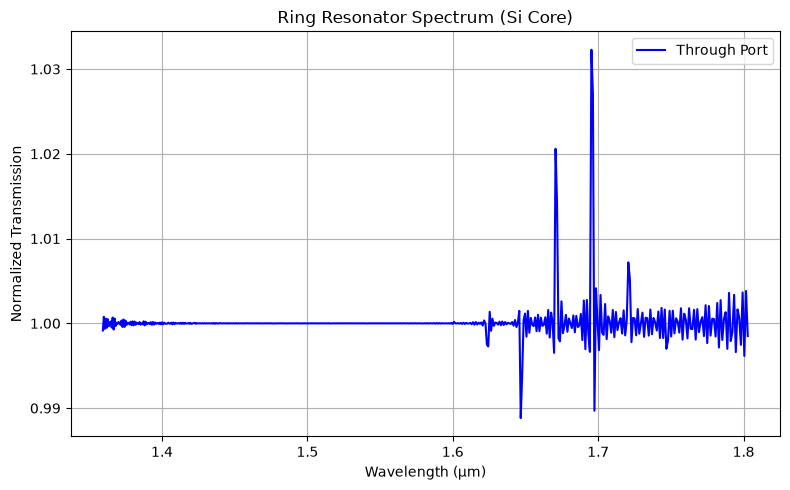

In [17]:
flux_freqs = mp.get_flux_freqs(trans)
wl = [1.0 / f for f in flux_freqs]
transmission = [r_f / s_f for r_f, s_f in zip(ring_flux, straight_flux)]

plt.figure(figsize=(8, 5))
plt.plot(wl, transmission, 'b-', label='Through Port')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Normalized Transmission')
plt.title('Ring Resonator Spectrum (Si Core)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()